In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib as mpl
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from datetime import datetime

import argparse
import os
import ast

import fsspec
import numpy as np
import pandas as pd
import xarray as xr
import goes2go
import pandas as pd
from tqdm import tqdm
from satpy import Scene

In [2]:
ibtracs_file = 'files/ibtracs.ALL.list.v04r01.csv'
ibtracs_na_file = 'files/ibtracs.NA.list.v04r01.csv' # North Atlantic
ibtracs_ep_file = 'files/ibtracs.EP.list.v04r01.csv' # Eastern Pacific
ibtracs_wp_file = 'files/ibtracs.WP.list.v04r01.csv' # Western Pacific
ibtracs_sp_file = 'files/ibtracs.SP.list.v04r01.csv' # South Pacific
ibtracs_si_file = 'files/ibtracs.SI.list.v04r01.csv' # South Indian
ibtracs_sa_file = 'files/ibtracs.SA.list.v04r01.csv' # South Atlantic
ibtracs_ni_file = 'files/ibtracs.NI.list.v04r01.csv' # North Indian Ocean

In [3]:
df = pd.read_csv(ibtracs_file, keep_default_na=False)
df_na = pd.read_csv(ibtracs_na_file, keep_default_na=False)
df_na['BASIN'] = ['NA'] * len(df_na)
df_ep = pd.read_csv(ibtracs_ep_file, keep_default_na=False)
df_ep['BASIN'] = ['EP'] * len(df_ep)
df_wp = pd.read_csv(ibtracs_wp_file, keep_default_na=False)
df_wp['BASIN'] = ['WP'] * len(df_wp)
df_sp = pd.read_csv(ibtracs_sp_file, keep_default_na=False)
df_sp['BASIN'] = ['SP'] * len(df_sp)
df_si = pd.read_csv(ibtracs_si_file, keep_default_na=False)
df_si['BASIN'] = ['SI'] * len(df_si)
df_sa = pd.read_csv(ibtracs_sa_file, keep_default_na=False)
df_sa['BASIN'] = ['SA'] * len(df_sa)
df_ni = pd.read_csv(ibtracs_ni_file, keep_default_na=False)
df_ni['BASIN'] = ['NI'] * len(df_ni)

/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_75585/2499292159.py:1: DtypeWarning: Columns (1,2,8,9,14,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ibtracs_file, keep_default_na=False)
/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_75585/2499292159.py:2: DtypeWarning: Columns (1,2,8,9,14,19,20,23,24,26,27,28,29,30,31,32,33,38,39,40,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_na = pd.read_csv(ibtracs_na_file, keep_default_na=False)
/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_75585/2499292159.py:4: DtypeWarning: Columns (1,2,8,9,14,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ep = pd.read_csv(ibtracs_ep_file, keep_default_na=False)
/var/folders/k9/_hm_155s5md_7xqqlb895t980000gn/T/ipykernel_75585/2499292159.py:6: DtypeWarning: Columns (1,2,8,9,14,142,143,144,172,173) have mixed types. Specify dtype option on

In [4]:
df_cyclobs = pd.read_csv('./files/master-cyclobs-[2023-2025].csv', keep_default_na=False)

In [9]:
# Combine all dataframes
df_all = pd.concat([df_na, df_ep, df_wp, df_sp, df_si, df_sa, df_ni], ignore_index=True)
# Filter for seasons 2023-2026
df_all = df_all[df_all['SEASON'].isin([2023, 2024, 2025])]
print('Number of storms before filtering for CYCLOBS storms: ', len(df_all['USA_ATCF_ID'].unique()))

Number of storms before filtering for CYCLOBS storms:  282


In [14]:
# Filter the storms that are also in TC PRIMED
cyclobs_storms = df_cyclobs.storm_id.unique()
df_matched = df_all[df_all['USA_ATCF_ID'].str.lower().isin(cyclobs_storms)]
print('Number of storms after filtering for CYCLOBS storms: ', len(df_matched['USA_ATCF_ID'].unique()))

Number of storms after filtering for CYCLOBS storms:  233


In [15]:
df_matched.head()


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
123849,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 00:00:00,ET,36.4,-71.3,...,,,,,,,,,7,55
123850,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 03:00:00,ET,36.6,-71.0,...,,,,,,,,,7,55
123851,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 06:00:00,ET,36.8,-70.6,...,,,,,,,,,8,55
123852,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 09:00:00,ET,37.0,-70.2,...,,,,,,,,,8,60
123853,2023015N36289,2023,3,NA,NA,UNNAMED,2023-01-15 12:00:00,ET,37.2,-69.7,...,,,,,,,,,8,70


### Filter Geostationary Fields-Of-View

In [16]:
GOES_EAST_COORDS = (-75.0, 0.0)  # Longitude, Latitude
GOES_WEST_COORDS = (-137.0, 0.0)  # Longitude, Latitude
HIMAWARI_COORDS = (140.7, 35.5)  # Longitude, Latitude

fov_bounds = {
    'GOES-East': {
        'lon_min': GOES_EAST_COORDS[0] - 60,
        'lon_max': GOES_EAST_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    },
    'GOES-West': {
        'lon_min': GOES_WEST_COORDS[0] - 60,
        'lon_max': GOES_WEST_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    },
    'Himawari': {
        'lon_min': HIMAWARI_COORDS[0] - 60,
        'lon_max': HIMAWARI_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    }
}

In [19]:
df_goes_tcs = df_matched[df_matched.LAT.between(-60, 60) & df_matched.LON.between(GOES_WEST_COORDS[0] - 60, GOES_EAST_COORDS[0] + 60)]
df_himawari_tcs = df_matched[df_matched.LAT.between(-60, 60) & df_matched.LON.between(HIMAWARI_COORDS[0] - 60, HIMAWARI_COORDS[0] + 60)]

In [20]:
len(df_goes_tcs.SID.unique()), len(df_himawari_tcs.SID.unique())

(100, 111)

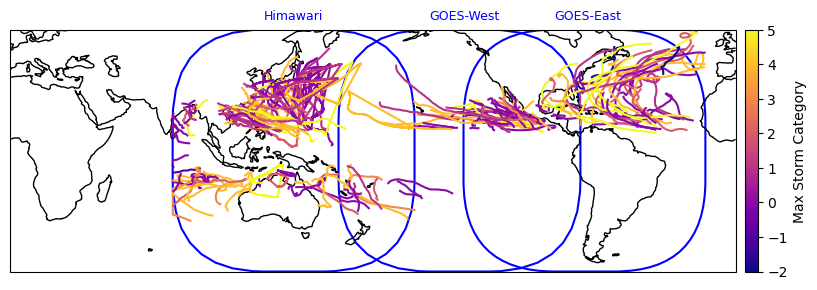

In [21]:
# Plot tracks on map
fig, ax = plt.subplots(figsize=(20, 3),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.set_extent([0, 359.99, -60, 60], crs=ccrs.PlateCarree())


# plot every track with colour for category
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=-2, vmax=5)

grouped = df_goes_tcs.groupby('SID')
for i, (name, group) in enumerate(grouped):
    max_cat = group['USA_SSHS'].max()
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color=cmap(norm(max_cat)))

grouped = df_himawari_tcs.groupby('SID')
for i, (name, group) in enumerate(grouped):
    max_cat = group['USA_SSHS'].max()
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color=cmap(norm(max_cat)))

# Draw Field of View boxes
for sat, bounds in fov_bounds.items():
    from matplotlib.patches import FancyBboxPatch

    patch = FancyBboxPatch(
        (bounds['lon_min'], bounds['lat_min']),
        bounds['lon_max'] - bounds['lon_min'],
        bounds['lat_max'] - bounds['lat_min'],
        boxstyle="round,pad=0,rounding_size=45",  # rounding_size in degrees
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        edgecolor='blue',
        facecolor='none'
    )
    ax.add_patch(patch)

    ax.text((bounds['lon_min'] + bounds['lon_max']) / 2 - 15, bounds['lat_max'] + 5, sat, transform=ccrs.PlateCarree(), fontsize=9, color='Blue')


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable with colorbar
plt.colorbar(sm, ax=ax, label='Max Storm Category', pad=0.005)
# plt.title('IBTrACS tracks from 2023 onwards')

plt.tight_layout()

In [22]:
df_goes_tcs.BASIN.unique() # Focus on North Atlantic and Eastern Pacific?

array(['NA', 'EP', 'SP'], dtype=object)

In [23]:
df_himawari_tcs.BASIN.unique() # Focus on Western and Southern Pacific?

array(['EP', 'WP', 'SP', 'SI', 'NI'], dtype=object)